# RB-F06：SABR較正の識別可能性

保存した較正・profile・SVD・holdoutから3図を描きます。価格の一致、パラメータの識別、数値安定性を分けて読みます。

In [1]:
import importlib.util
import os
import sys
from pathlib import Path

import numpy as np
from IPython.display import Markdown, display
from hullkit import nbplot

get_ipython().run_line_magic("matplotlib", "inline")
plt = nbplot.setup()
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

def resolve_directory(variable, filename):
    supplied = os.environ.get(variable)
    candidates = [Path(supplied)] if supplied else [Path.cwd()]
    if not supplied:
        candidates += [parent / "johnhull/research/RB-F06"
                       for parent in [Path.cwd(), *Path.cwd().parents]]
    for candidate in candidates:
        if (candidate / filename).is_file():
            return candidate
    raise FileNotFoundError("Saved RB-F06 data/source missing; set " + variable)

artifact_dir = resolve_directory("JOHNHULL_SABR_IDENTIFIABILITY_ARTIFACTS_DIR", "reference.json")
source_dir = resolve_directory("JOHNHULL_SABR_IDENTIFIABILITY_SOURCE_DIR", "build_reference.py")
spec = importlib.util.spec_from_file_location("rbf06_notebook_saved_loader", source_dir / "build_reference.py")
loader = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = loader
spec.loader.exec_module(loader)

def artifact_forbidden(*args, **kwargs):
    raise RuntimeError("Artifact-only guard: RNG, optimization and fresh work are forbidden")

# Install before saved checking: the kernel may read/revalue but must not draw or fit.
import scipy.optimize as _optimizer
artifact_guard_rng = ["default_rng", "RandomState", "SeedSequence", "seed", "rand", "randn",
                      "random", "random_sample", "normal", "standard_normal", "uniform",
                      "poisson", "choice", "permutation", "shuffle"]
artifact_guard_optimizer = ["least_squares", "minimize", "differential_evolution",
                            "dual_annealing", "basinhopping"]
for _name in artifact_guard_rng:
    setattr(np.random, _name, artifact_forbidden)
for _name in artifact_guard_optimizer:
    setattr(_optimizer, _name, artifact_forbidden)
if hasattr(loader, "core"):
    loader.core.fit_smile = artifact_forbidden
    if hasattr(loader.core, "least_squares"):
        loader.core.least_squares = artifact_forbidden
for _name in ["run_study", "_fresh"]:
    if hasattr(loader, _name):
        setattr(loader, _name, artifact_forbidden)
print("Artifact guard active before saved checking:",
      len(artifact_guard_rng), "RNG entries and", len(artifact_guard_optimizer), "optimizer entries")
record, arrays = loader.load_result(artifact_dir)
if record["phase"] not in {"main", "fixture"}:
    raise ValueError("pilot has no held-out study and cannot populate this notebook")
checked = loader.check_record(record, arrays, fresh=False)
if checked.get("passed") is not True:
    raise ValueError("Saved RB-F06 checker failed")
summary = loader.module("analytics").summarize(record, arrays)
protocol = record["protocol"]
phase = record["phase"]
axis_names = ["a", "rho", "nu"]
groups = list(protocol["groups"])
truths = protocol["truths"]
rep = protocol["representative_noisy_rep"]
dataset_map = {(d["truth_index"], d["group"], d["rep"]): d for d in record["datasets"]}
row_map = {r["dataset_id"]: r for r in summary["per_dataset"]}
cells = summary["cells"]
cell_map = {(c["truth_index"], c["group"]): c for c in cells}
identities = [(ti, group) for ti in range(len(truths)) for group in groups]
labels = [truths[ti]["name"] + "\n" + group for ti, group in identities]
positions = np.arange(len(identities))
representatives = [dataset_map.get((ti, group, rep)) for ti, group in identities]

def number(value):
    return "unknown" if value is None else f"{value:.5g}"

def table(headers, rows):
    def clean(value):
        return str(value).replace("|", "/").replace("\n", " ")
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"]*len(headers)) + " |"]
    lines += ["| " + " | ".join(clean(value) for value in row) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

def finish_figure(fig, title, note):
    fig.suptitle(title + " | " + phase + " | saved artifact only", fontsize=12)
    fig.text(.5, .012, note, ha="center", va="bottom", fontsize=9)
    fig.tight_layout(rect=(0, .07, 1, .945))
    display(fig)
    plt.close(fig)

def chosen_fit(dataset):
    if dataset is None:
        return None
    fid = row_map[dataset["dataset_id"]]["best_converged"]
    return next((fit for fit in dataset["fits"] if fit["fit_id"] == fid), None)

def tick_cells(ax):
    ax.set_xticks(positions, labels, fontsize=8)
    ax.grid(axis="y", alpha=.2)

print("Saved-artifact phase:", phase, "| numerical checker:", checked["passed"])
print("fixture / 未受入: 表示配線の確認専用。" if phase == "fixture"
      else "保存された主実験です。独立研究受入の正本はREADME/REVIEWで確認してください。")
print("record teaching_acceptance:", record["teaching_acceptance"],
      "| independent research acceptance is separate from this numerical checker.")
print("Approximate Hagan IV map only; exact SABR prices/dynamics are not validated.")
print("No RNG, optimizer, training, network, or fresh calculation is run in this notebook.")
print("theta=(a,rho,nu), a=alpha/F**(1-beta); u=theta/parameter_scale:",
      protocol["parameter_scale"], "| IV noise scale:", protocol["noise_scale"])
print("Frozen representative noisy repetition:", rep,
      "| pointwise chi-square descriptive reference:", number(protocol["profile_threshold"]))
print("Boundary/nonidentification LR coverage is unverified. This is not a joint confidence envelope.")
print("Finite visited profiles do not explore all interiors: unexplored gaps may contain extra crossings.")
print("Original dataset slots:", len(record["datasets"]),
      "| noisy slots:", sum(d["rep"] >= 0 for d in record["datasets"]),
      "| recorded seed slots:", len(protocol["seed_ledger"]))
table(["cost item", "recorded value"], [[key, number(record["costs"].get(key))]
      for key in ["solver_calls", "exceptions", "evaluation_count_unknown",
                  "attempt_seconds", "solver_seconds", "diagnostic_seconds"]])
print("Recorded attempt/solver/diagnostic times are nested, not additive independent categories.")
print("Runtime invocation seconds:", number(record["runtime"].get("invocation_seconds")),
      "| scope:", record["runtime"].get("cost_scope"))
print("Saved analytics attempts:", summary["cost_totals"]["attempts"],
      "| failed:", summary["cost_totals"]["failed"],
      "| boundary attempts:", summary["cost_totals"]["boundary_attempts"])


Artifact guard active before saved checking: 15 RNG entries and 5 optimizer entries


Saved-artifact phase: main | numerical checker: True
保存された主実験です。独立研究受入の正本はREADME/REVIEWで確認してください。
record teaching_acceptance: False | independent research acceptance is separate from this numerical checker.
Approximate Hagan IV map only; exact SABR prices/dynamics are not validated.
No RNG, optimizer, training, network, or fresh calculation is run in this notebook.
theta=(a,rho,nu), a=alpha/F**(1-beta); u=theta/parameter_scale: [0.2, 0.5, 0.5] | IV noise scale: 0.0005
Frozen representative noisy repetition: 0 | pointwise chi-square descriptive reference: 3.8415
Boundary/nonidentification LR coverage is unverified. This is not a joint confidence envelope.
Finite visited profiles do not explore all interiors: unexplored gaps may contain extra crossings.
Original dataset slots: 102 | noisy slots: 96 | recorded seed slots: 40


| cost item | recorded value |
| --- | --- |
| solver_calls | 4398 |
| exceptions | 0 |
| evaluation_count_unknown | 0 |
| attempt_seconds | 20.381 |
| solver_seconds | 18.588 |
| diagnostic_seconds | 0.58953 |

Recorded attempt/solver/diagnostic times are nested, not additive independent categories.
Runtime invocation seconds: 191.47 | scope: fit work sums survive resume; invocation includes checkpoint/I/O and setup for this invocation
Saved analytics attempts: 4398 | failed: 5 | boundary attempts: 1646


## 1. Profileとslice

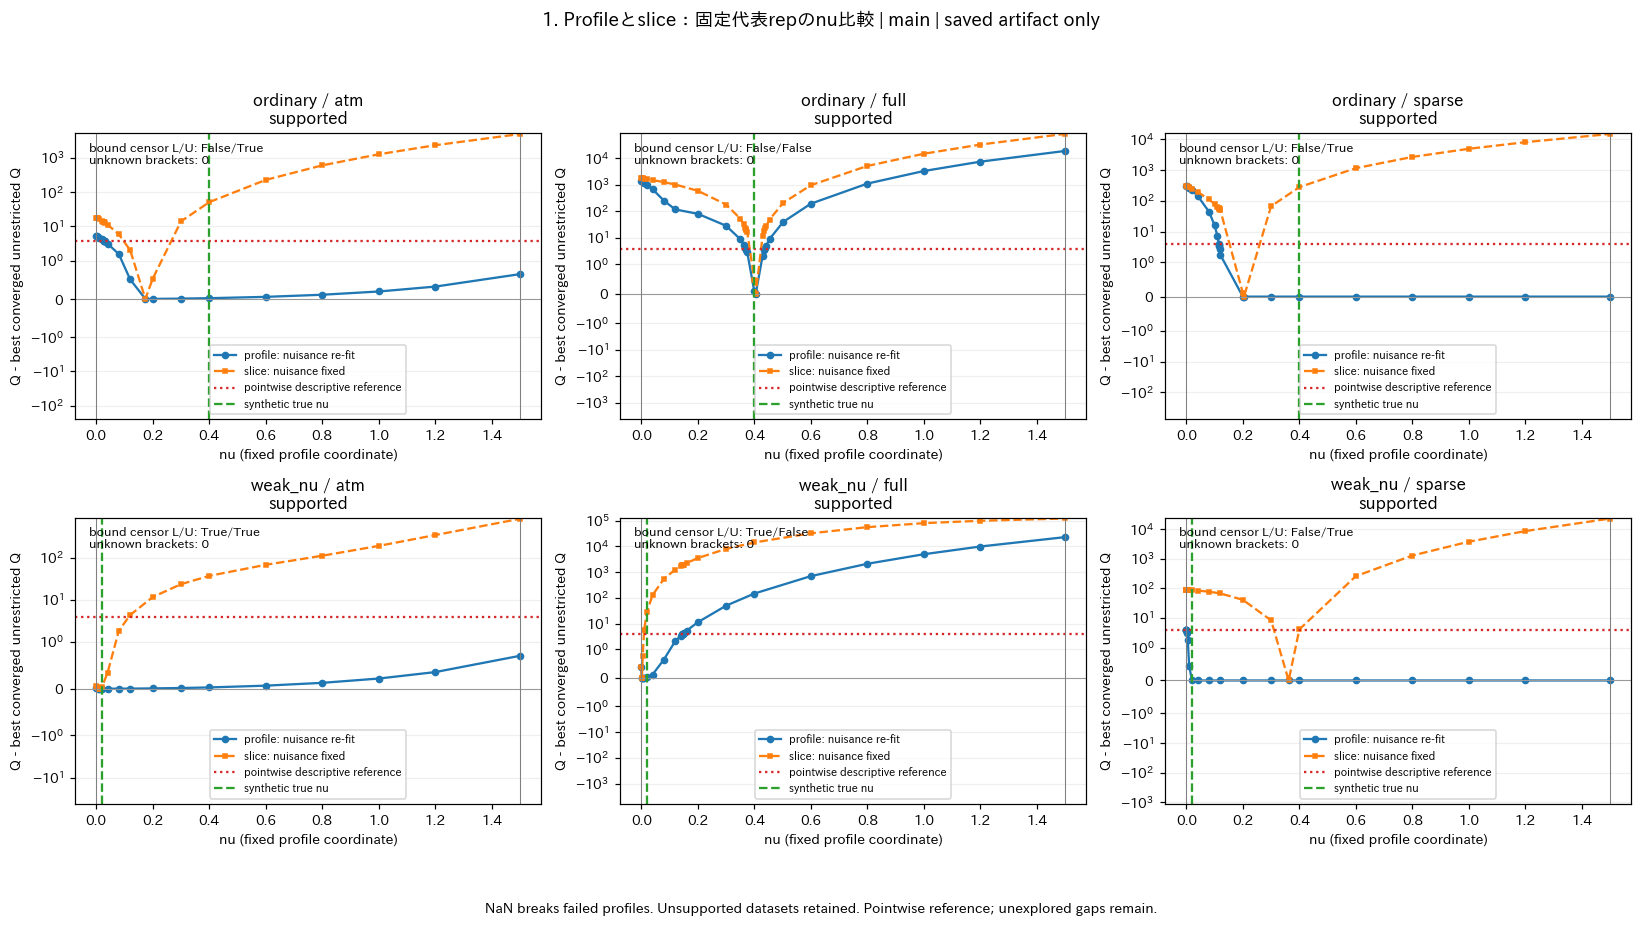

| truth | group | rep | axis | support | visited points | failed/unknown | sampled components (ΔQ-only) | bound censor L/U | unknown brackets | reference delta Q |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ordinary | atm | -1 | nu | supported_with_unknown | 29 | 0 | [[0.39218749998034125, 0.40625]] | False/False | 0 | 1e-06 |
| ordinary | full | -1 | nu | supported_with_unknown | 29 | 0 | [[0.4, 0.40000000000000946]] | False/False | 0 | 1e-06 |
| ordinary | sparse | -1 | nu | supported_with_unknown | 23 | 0 | [[0.125, 1.5]] | False/True | 0 | 1e-06 |
| ordinary | atm | 0 | a | supported | 26 | 0 | [[0.1696875, 0.2037554241780119]] | False/False | 0 | 3.8415 |
| ordinary | atm | 0 | rho | supported | 25 | 0 | [[-0.95, -0.022265625000000004]] | True/False | 0 | 3.8415 |
| ordinary | atm | 0 | nu | supported | 23 | 0 | [[0.026875000000000003, 1.5]] | False/True | 0 | 3.8415 |
| ordinary | full | 0 | a | supported | 26 | 0 | [[0.19927458966788228, 0.200625]] | False/False | 0 | 3.8415 |
| ordinary | full | 0 | rho | supported | 31 | 0 | [[-0.3263671875, -0.27454388116018114]] | False/False | 0 | 3.8415 |
| ordinary | full | 0 | nu | supported | 29 | 0 | [[0.37031250000000004, 0.43548318827820576]] | False/False | 0 | 3.8415 |
| ordinary | sparse | 0 | a | supported | 26 | 0 | [[0.15140625, 0.20440863117628502]] | False/False | 0 | 3.8415 |
| ordinary | sparse | 0 | rho | supported | 25 | 0 | [[-0.95, -0.09648437500000001]] | True/False | 0 | 3.8415 |
| ordinary | sparse | 0 | nu | supported | 23 | 0 | [[0.11562499999999999, 1.5]] | False/True | 0 | 3.8415 |
| weak_nu | atm | -1 | nu | supported_with_unknown | 29 | 0 | [[0.00625, 0.0875]] | False/False | 0 | 1e-06 |
| weak_nu | full | -1 | nu | supported_with_unknown | 29 | 0 | [[0.019687500000000004, 0.020312500001040935]] | False/False | 0 | 1e-06 |
| weak_nu | sparse | -1 | nu | supported_with_unknown | 23 | 0 | [[0.006328125, 1.5]] | False/True | 0 | 1e-06 |
| weak_nu | atm | 0 | a | supported | 26 | 0 | [[0.16828125, 0.20118116153681442]] | False/False | 0 | 3.8415 |
| weak_nu | atm | 0 | rho | supported | 19 | 0 | [[-0.95, 0.95]] | True/True | 0 | 3.8415 |
| weak_nu | atm | 0 | nu | supported | 17 | 0 | [[0.0, 1.5]] | True/True | 0 | 3.8415 |
| weak_nu | full | 0 | a | supported | 26 | 0 | [[0.19968750000000002, 0.2006331618593274]] | False/False | 0 | 3.8415 |
| weak_nu | full | 0 | rho | supported | 19 | 0 | [[-0.95, 0.95]] | True/True | 0 | 3.8415 |
| weak_nu | full | 0 | nu | supported | 23 | 0 | [[0.0, 0.14500000000000002]] | True/False | 0 | 3.8415 |
| weak_nu | sparse | 0 | a | supported | 26 | 0 | [[0.148125, 0.20125]] | False/False | 0 | 3.8415 |
| weak_nu | sparse | 0 | rho | supported | 25 | 0 | [[-0.95, -0.0033087249555173687]] | True/False | 0 | 3.8415 |
| weak_nu | sparse | 0 | nu | supported | 23 | 0 | [[0.0003125, 1.5]] | False/True | 0 | 3.8415 |

表は全curve・全3軸を収録します。sampled componentsは区間全体の支持を保証しません。
Noiseless curve/table: ΔQ-only sampled components; noiseless same-fit price visits additionally require max IV residual<=1e-9.
Noisy curves use pointwise descriptive chi-square reference; noiseless curves use their separate tiny delta-Q tolerance.
Missing curve stays missing. A feasible slice can remain finite when the profile optimizer fails.


In [2]:
fig, axes = plt.subplots(len(truths), len(groups), figsize=(15, 8.5), squeeze=False)
profile_table = []
for ti, truth in enumerate(truths):
    for gi, group in enumerate(groups):
        ax = axes[ti, gi]
        dataset = dataset_map.get((ti, group, rep))
        if dataset is None:
            ax.set_axis_off()
            ax.text(.5, .5, "missing representative dataset\n" + truth["name"] + " / " + group,
                    ha="center", va="center", transform=ax.transAxes)
            continue
        row = row_map[dataset["dataset_id"]]
        curve = next((c for c in dataset["curves"] if c["axis"] == 2), None)
        baseline = row["best_q"]
        ax.set_title(truth["name"] + " / " + group + "\n" + row["support"]["status"])
        if curve is None or baseline is None:
            ax.text(.5, .5, "missing curve / no converged baseline",
                    ha="center", transform=ax.transAxes)
            continue
        point_map = {p["point_id"]: p for p in dataset["profile_points"]}
        points = sorted([point_map[pid] for pid in curve["point_ids"]], key=lambda p: p["value"])
        x = [point["value"] for point in points]
        profile_q = [point["q"] - baseline if point["success"] and point["q"] is not None
                     and np.isfinite(point["q"]) else np.nan for point in points]
        slice_q = [np.nan if point["slice_q"] is None else point["slice_q"] - baseline for point in points]
        ax.plot(x, profile_q, "o-", markersize=4, label="profile: nuisance re-fit")
        ax.plot(x, slice_q, "s--", markersize=3, label="slice: nuisance fixed")
        ax.axhline(curve["threshold"], color="tab:red", linestyle=":",
                   label="pointwise descriptive reference")
        ax.axhline(0, color=".6", linewidth=.7)
        ax.axvline(truth["theta"][2], color="tab:green", linestyle="--", label="synthetic true nu")
        for bound in [protocol["bounds"][0][2], protocol["bounds"][1][2]]:
            ax.axvline(bound, color=".5", linewidth=.7)
        failed_x = [value for value, q in zip(x, profile_q, strict=True) if not np.isfinite(q)]
        if failed_x:
            ax.scatter(failed_x, [.04]*len(failed_x), transform=ax.get_xaxis_transform(),
                       marker="x", color="black", label="failed / unknown (gap)")
        segments = curve["segments"]
        ax.text(.03, .97, "bound censor L/U: " + str(segments.get("lower_censored")) + "/"
                + str(segments.get("upper_censored")) + "\nunknown brackets: "
                + str(len(segments.get("unknown_brackets", []))),
                transform=ax.transAxes, va="top", fontsize=8)
        ax.set_yscale("symlog", linthresh=1.)
        ax.set_xlabel("nu (fixed profile coordinate)")
        ax.set_ylabel("Q - best converged unrestricted Q")
        ax.legend(fontsize=7, loc="best")
        ax.grid(axis="y", alpha=.2)
finish_figure(fig, "1. Profileとslice：固定代表repのnu比較",
              "NaN breaks failed profiles. Unsupported datasets retained. Pointwise reference; unexplored gaps remain.")
for dataset in record["datasets"]:
    for curve in dataset["curves"]:
        point_map = {p["point_id"]: p for p in dataset["profile_points"]}
        points = [point_map[pid] for pid in curve["point_ids"]]
        segments = curve["segments"]
        profile_table.append([
            truths[dataset["truth_index"]]["name"], dataset["group"], dataset["rep"],
            axis_names[curve["axis"]], row_map[dataset["dataset_id"]]["support"]["status"],
            len(points), sum(not p["success"] or p["q"] is None for p in points),
            segments.get("observed_components", "unknown"),
            str(segments.get("lower_censored")) + "/" + str(segments.get("upper_censored")),
            len(segments.get("unknown_brackets", [])), number(curve["threshold"]),
        ])
table(["truth", "group", "rep", "axis", "support", "visited points", "failed/unknown",
       "sampled components (ΔQ-only)", "bound censor L/U", "unknown brackets", "reference delta Q"], profile_table)
print("表は全curve・全3軸を収録します。sampled componentsは区間全体の支持を保証しません。")
print("Noiseless curve/table: ΔQ-only sampled components; noiseless same-fit price visits additionally require max IV residual<=1e-9.")
print("Noisy curves use pointwise descriptive chi-square reference; noiseless curves use their separate tiny delta-Q tolerance.")
print("Missing curve stays missing. A feasible slice can remain finite when the profile optimizer fails.")


## 2. Scaled SVDと弱方向

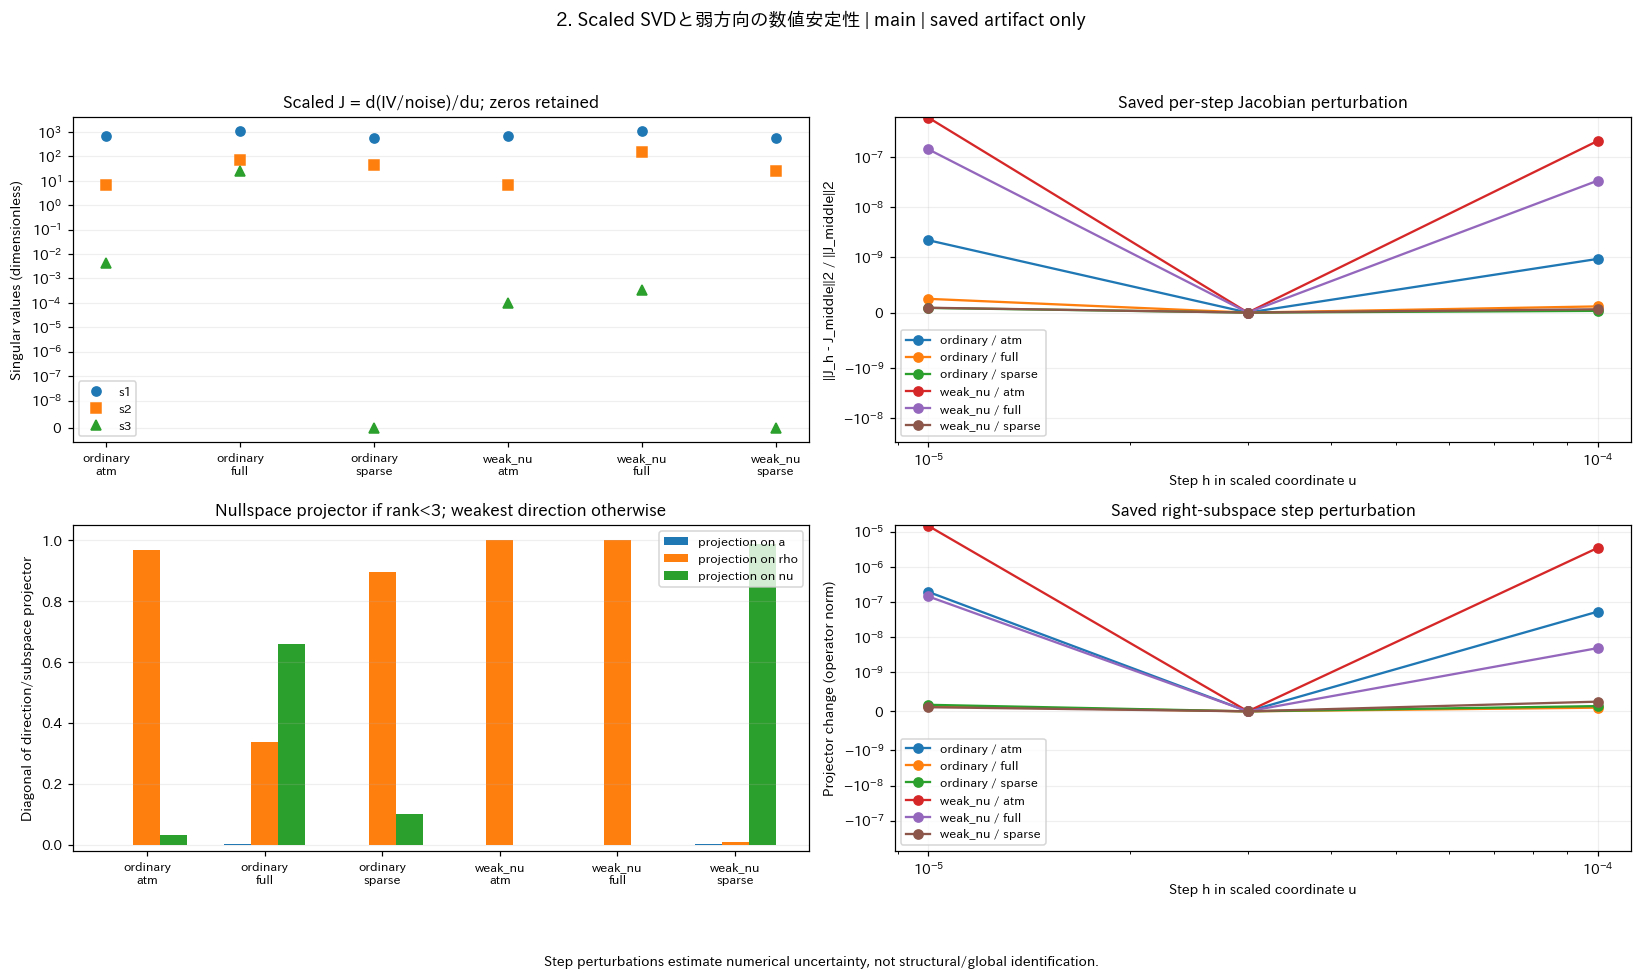

| truth/group | numerical rank | scaled condition | step stability | ranks by step | maximum relative change (scalar) | smallest nonzero SV / estimated error | boundary flags a/rho/nu |
| --- | --- | --- | --- | --- | --- | --- | --- |
| ordinary/atm | 3 | 1.6425e+05 | stable_estimate | [3, 3, 3] | 2.1666e-09 | 2810.1 | [False, True, False] |
| ordinary/full | 3 | 43.65 | stable_estimate | [3, 3, 3] | 2.4751e-10 | 9.2558e+07 | [False, False, False] |
| ordinary/sparse | 2 | unknown | stable_estimate | [2, 2, 2] | 8.3843e-11 | 9.4593e+08 | [False, False, False] |
| weak_nu/atm | 3 | 7.0048e+06 | numerical_unresolved | [3, 3, 3] | 6.1115e-07 | 0.23359 | [False, True, False] |
| weak_nu/full | 3 | 3.2377e+06 | numerical_unresolved | [3, 3, 3] | 1.4235e-07 | 2.1697 | [False, True, False] |
| weak_nu/sparse | 2 | unknown | stable_estimate | [2, 2, 2] | 8.7541e-11 | 5.1277e+08 | [False, False, False] |

図の3点は保存済みJacobian行列から各stepの相対差を計算した表示値です。
summary relative_matrix_changeは3点の最大値1個で、数値安定性の判定に使うscalarです。
右特異ベクトルの符号は同定しません。欠損rankではnullspace全体のprojectorを表示します。
rank<2では単一の弱方向は一意ではありません。scaled conditionのunknownを有限値へ置換しません。
安定な数値推定もglobal identificationの証明ではありません。nu=0境界とtiny-positive nuを区別します。


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
sv = np.full((len(identities), 3), np.nan)
projection = np.full_like(sv, np.nan)
stability_table = []
for index, dataset in enumerate(representatives):
    fit = chosen_fit(dataset)
    if fit is None:
        for ax in [axes[0, 0], axes[1, 0]]:
            ax.text(index, .02, "missing", transform=ax.get_xaxis_transform(),
                    rotation=90, fontsize=7)
        continue
    keys = fit["array_keys"]
    sv[index] = arrays[keys["singular_values"]]
    vectors = arrays[keys["right_vectors"]]
    # The entire numerical nullspace is basis invariant when rank<3.
    subspace = vectors[fit["rank"]:] if fit["rank"] < 3 else vectors[-1:]
    projection[index] = np.sum(subspace**2, axis=0)
    stability = fit.get("numerical_stability")
    if stability is not None:
        step_jacobians = np.asarray(arrays[fit["stability_jacobians_key"]], dtype=float)
        if step_jacobians.ndim != 3 or len(step_jacobians) != len(protocol["jacobian_steps_u"]):
            raise ValueError("Saved stability Jacobian steps do not match the protocol")
        middle_jacobian = step_jacobians[len(step_jacobians)//2]
        middle_norm = max(float(np.linalg.norm(middle_jacobian, 2)), np.finfo(float).tiny)
        relative_changes_by_step = [float(np.linalg.norm(j-middle_jacobian, 2))/middle_norm
                                    for j in step_jacobians]
        axes[0, 1].plot(protocol["jacobian_steps_u"], relative_changes_by_step,
                        "o-", label=labels[index].replace("\n", " / "))
        axes[1, 1].plot(protocol["jacobian_steps_u"], stability["direction_projector_changes"],
                        "o-", label=labels[index].replace("\n", " / "))
    stability_table.append([
        labels[index].replace("\n", "/"), fit["rank"], number(fit["condition"]),
        "unknown" if stability is None else stability["status"],
        "unknown" if stability is None else stability["ranks"],
        "unknown" if stability is None else number(stability["relative_matrix_change"]),
        "unknown" if stability is None else number(stability["smallest_nonzero_to_estimated_error"]),
        np.asarray(arrays[keys["boundary_flags"]]).tolist(),
    ])
for axis, marker in enumerate(["o", "s", "^"]):
    axes[0, 0].plot(positions, sv[:, axis], marker, linestyle="none", label="s" + str(axis+1))
    axes[1, 0].bar(positions + (axis-1)*.23, projection[:, axis], width=.23,
                    label="projection on " + axis_names[axis])
axes[0, 0].set_yscale("symlog", linthresh=1e-8)
axes[0, 0].set_title("Scaled J = d(IV/noise)/du; zeros retained")
axes[0, 0].set_ylabel("Singular values (dimensionless)")
axes[1, 0].set_title("Nullspace projector if rank<3; weakest direction otherwise")
axes[1, 0].set_ylabel("Diagonal of direction/subspace projector")
axes[1, 0].set_ylim(-.02, 1.05)
for ax in [axes[0, 0], axes[1, 0]]:
    tick_cells(ax)
    ax.legend(fontsize=8)
for ax, title, ylabel in [
    (axes[0, 1], "Saved per-step Jacobian perturbation", "||J_h - J_middle||2 / ||J_middle||2"),
    (axes[1, 1], "Saved right-subspace step perturbation", "Projector change (operator norm)")]:
    ax.set_xscale("log")
    ax.set_yscale("symlog", linthresh=1e-9)
    ax.set_title(title)
    ax.set_xlabel("Step h in scaled coordinate u")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=.2)
    if ax.lines:
        ax.legend(fontsize=8)
    else:
        ax.text(.5, .5, "missing stability diagnostics", transform=ax.transAxes, ha="center")
finish_figure(fig, "2. Scaled SVDと弱方向の数値安定性",
              "Step perturbations estimate numerical uncertainty, not structural/global identification.")
table(["truth/group", "numerical rank", "scaled condition", "step stability", "ranks by step",
       "maximum relative change (scalar)", "smallest nonzero SV / estimated error",
       "boundary flags a/rho/nu"], stability_table)
print("図の3点は保存済みJacobian行列から各stepの相対差を計算した表示値です。")
print("summary relative_matrix_changeは3点の最大値1個で、数値安定性の判定に使うscalarです。")
print("右特異ベクトルの符号は同定しません。欠損rankではnullspace全体のprojectorを表示します。")
print("rank<2では単一の弱方向は一意ではありません。scaled conditionのunknownを有限値へ置換しません。")
print("安定な数値推定もglobal identificationの証明ではありません。nu=0境界とtiny-positive nuを区別します。")


## 3. Noise反復とholdout価格幅

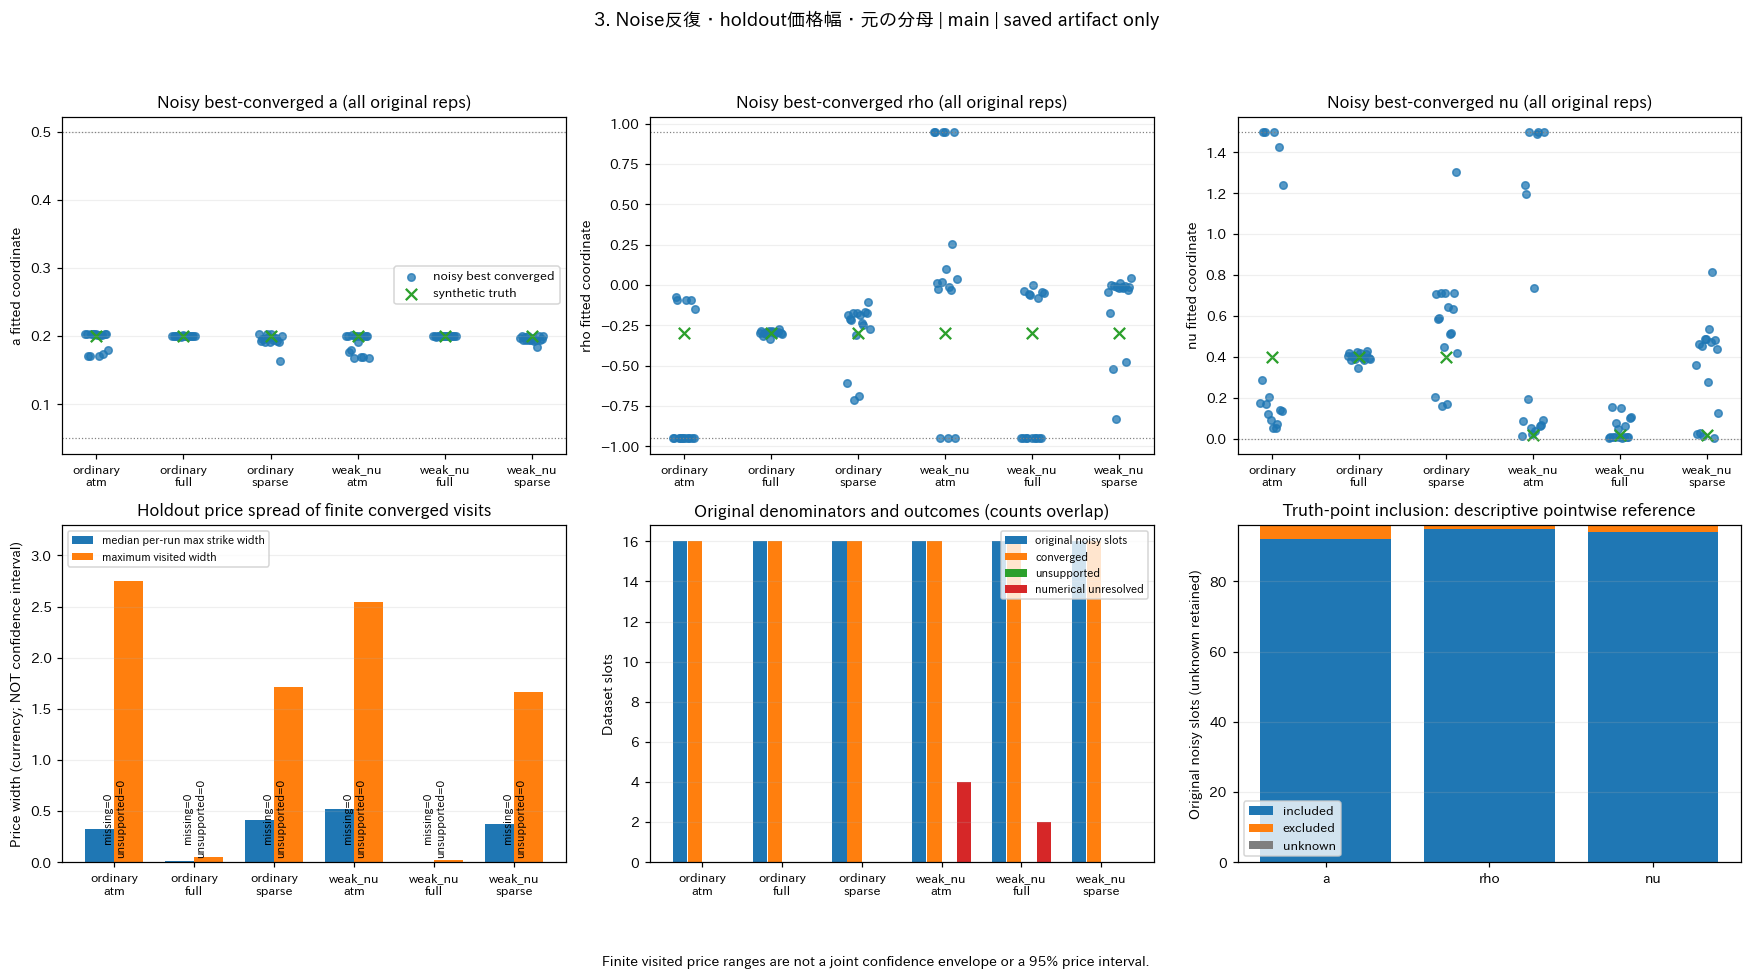

| truth/group | original noisy | converged | unsupported | J unresolved | best on bound | range missing | range unsupported | max best-fit IV error | max best-fit price error |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ordinary/atm | 16 | 16 | 0 | 0 | 14 | 0 | 0 | 0.088306 | 2.1362 |
| ordinary/full | 16 | 16 | 0 | 0 | 0 | 0 | 0 | 0.0017124 | 0.033886 |
| ordinary/sparse | 16 | 16 | 0 | 0 | 0 | 0 | 0 | 0.054544 | 1.2029 |
| weak_nu/atm | 16 | 16 | 0 | 4 | 11 | 0 | 0 | 0.095435 | 2.3947 |
| weak_nu/full | 16 | 16 | 0 | 2 | 9 | 0 | 0 | 0.0019901 | 0.037022 |
| weak_nu/sparse | 16 | 16 | 0 | 0 | 0 | 0 | 0 | 0.026938 | 0.55614 |

| truth/group | holdout log(K/F) | kind | runs with visited range | original runs | maximum visited price width (currency) |
| --- | --- | --- | --- | --- | --- |
| ordinary/atm | -0.15 | interpolation | 16 | 16 | 1.425 |
| ordinary/atm | -0.05 | interpolation | 16 | 16 | 0.34134 |
| ordinary/atm | 0.05 | interpolation | 16 | 16 | 0.4664 |
| ordinary/atm | 0.15 | interpolation | 16 | 16 | 2.019 |
| ordinary/atm | -0.25 | extrapolation | 16 | 16 | 2.0667 |
| ordinary/atm | 0.25 | extrapolation | 16 | 16 | 2.7451 |
| ordinary/full | -0.15 | interpolation | 16 | 16 | 0.014455 |
| ordinary/full | -0.05 | interpolation | 16 | 16 | 0.022684 |
| ordinary/full | 0.05 | interpolation | 16 | 16 | 0.02655 |
| ordinary/full | 0.15 | interpolation | 16 | 16 | 0.024759 |
| ordinary/full | -0.25 | extrapolation | 16 | 16 | 0.036807 |
| ordinary/full | 0.25 | extrapolation | 16 | 16 | 0.047671 |
| ordinary/sparse | -0.15 | interpolation | 16 | 16 | 0.60321 |
| ordinary/sparse | -0.05 | interpolation | 16 | 16 | 0.64936 |
| ordinary/sparse | 0.05 | interpolation | 16 | 16 | 0.73718 |
| ordinary/sparse | 0.15 | interpolation | 16 | 16 | 0.78333 |
| ordinary/sparse | -0.25 | extrapolation | 16 | 16 | 1.3654 |
| ordinary/sparse | 0.25 | extrapolation | 16 | 16 | 1.7149 |
| weak_nu/atm | -0.15 | interpolation | 16 | 16 | 1.2784 |
| weak_nu/atm | -0.05 | interpolation | 16 | 16 | 0.25508 |
| weak_nu/atm | 0.05 | interpolation | 16 | 16 | 0.35767 |
| weak_nu/atm | 0.15 | interpolation | 16 | 16 | 1.7446 |
| weak_nu/atm | -0.25 | extrapolation | 16 | 16 | 1.9113 |
| weak_nu/atm | 0.25 | extrapolation | 16 | 16 | 2.5443 |
| weak_nu/full | -0.15 | interpolation | 16 | 16 | 0.013681 |
| weak_nu/full | -0.05 | interpolation | 16 | 16 | 0.024017 |
| weak_nu/full | 0.05 | interpolation | 16 | 16 | 0.024395 |
| weak_nu/full | 0.15 | interpolation | 16 | 16 | 0.0097362 |
| weak_nu/full | -0.25 | extrapolation | 16 | 16 | 0.018548 |
| weak_nu/full | 0.25 | extrapolation | 16 | 16 | 0.019475 |
| weak_nu/sparse | -0.15 | interpolation | 16 | 16 | 0.63762 |
| weak_nu/sparse | -0.05 | interpolation | 16 | 16 | 0.6819 |
| weak_nu/sparse | 0.05 | interpolation | 16 | 16 | 0.73359 |
| weak_nu/sparse | 0.15 | interpolation | 16 | 16 | 0.72473 |
| weak_nu/sparse | -0.25 | extrapolation | 16 | 16 | 1.4095 |
| weak_nu/sparse | 0.25 | extrapolation | 16 | 16 | 1.6618 |

| truth/group | axis | original denominator | included | excluded | unknown | original fraction bounds | known denominator | known-only rate | known-only Wilson uncertainty |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ordinary/atm | a | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| ordinary/atm | rho | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| ordinary/atm | nu | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| ordinary/full | a | 16 | 15 | 1 | 0 | [0.9375, 0.9375] | 16 | 0.9375 | [0.7167126242970107, 0.9888806552353576] |
| ordinary/full | rho | 16 | 15 | 1 | 0 | [0.9375, 0.9375] | 16 | 0.9375 | [0.7167126242970107, 0.9888806552353576] |
| ordinary/full | nu | 16 | 15 | 1 | 0 | [0.9375, 0.9375] | 16 | 0.9375 | [0.7167126242970107, 0.9888806552353576] |
| ordinary/sparse | a | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| ordinary/sparse | rho | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| ordinary/sparse | nu | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| weak_nu/atm | a | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| weak_nu/atm | rho | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| weak_nu/atm | nu | 16 | 15 | 1 | 0 | [0.9375, 0.9375] | 16 | 0.9375 | [0.7167126242970107, 0.9888806552353576] |
| weak_nu/full | a | 16 | 15 | 1 | 0 | [0.9375, 0.9375] | 16 | 0.9375 | [0.7167126242970107, 0.9888806552353576] |
| weak_nu/full | rho | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| weak_nu/full | nu | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| weak_nu/sparse | a | 16 | 14 | 2 | 0 | [0.875, 0.875] | 16 | 0.875 | [0.639771727342413, 0.9650225122567595] |
| weak_nu/sparse | rho | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |
| weak_nu/sparse | nu | 16 | 16 | 0 | 0 | [1.0, 1.0] | 16 | 1 | [0.8063923194655637, 1.0] |

Pointwise inclusion is descriptive; known-only Wilson uncertainty is not certified LR coverage.
範囲はfinite converged visitsのmin/maxです。未訪問の解やunsupportedの状態を消しません。
Holdout IV/価格誤差は同じHagan近似mapに対する合成実験です。exact SABRや実市場への外的妥当性ではありません。


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
width_medians, width_maxima, range_missing, range_unsupported = [], [], [], []
count_rows, holdout_rows = [], []
for index, (ti, group) in enumerate(identities):
    rows = [r for r in summary["per_dataset"] if (r["truth_index"], r["group"]) == (ti, group)
            and r["rep"] >= 0]
    solved = [r for r in rows if r["theta"] is not None]
    offsets = np.linspace(-.13, .13, len(solved)) if solved else []
    for axis in range(3):
        ax = axes[0, axis]
        if solved:
            ax.scatter(index + offsets, [row["theta"][axis] for row in solved],
                       s=24, color="tab:blue", alpha=.75, label="noisy best converged" if index == 0 else None)
        ax.scatter([index], [truths[ti]["theta"][axis]], marker="x", color="tab:green", s=55,
                   label="synthetic truth" if index == 0 else None)
        if not rows:
            ax.text(index, .03, "missing dataset",
                    rotation=90, transform=ax.get_xaxis_transform(), fontsize=7)
        elif len(solved) < len(rows):
            ax.text(index, .03, f"missing {len(rows)-len(solved)}/{len(rows)}",
                    rotation=90, transform=ax.get_xaxis_transform(), fontsize=7)
    ranges = [row["sampled_price_range"] for row in rows if row["sampled_price_range"] is not None]
    maxima = [max(item["width"]) for item in ranges]
    width_medians.append(float(np.median(maxima)) if maxima else np.nan)
    width_maxima.append(max(maxima) if maxima else np.nan)
    range_missing.append(len(rows)-len(ranges))
    range_unsupported.append(sum(item["support_status"] == "unsupported" for item in ranges))
    cell = cell_map.get((ti, group))
    if cell is not None:
        flags = 0
        for row in rows:
            dataset = next(d for d in record["datasets"] if d["dataset_id"] == row["dataset_id"])
            fit = chosen_fit(dataset)
            if fit is not None:
                key = fit["array_keys"]["boundary_flags"]
                flags += int(np.any(arrays[key]))
        count_rows.append([
            labels[index].replace("\n", "/"), cell["original_noisy_slots"], cell["converged_noisy_slots"],
            cell["unsupported_noisy_slots"], cell["jacobian_unresolved_slots"], flags,
            range_missing[-1], range_unsupported[-1], number(cell["max_holdout_iv_error"]),
            number(cell["max_holdout_price_error"]),
        ])
    for strike_index, log_moneyness in enumerate(protocol["holdout_log_moneyness"]):
        holdout_rows.append([
            labels[index].replace("\n", "/"), number(log_moneyness), protocol["holdout_kind"][strike_index],
            len(ranges), len(rows), number(max((item["width"][strike_index] for item in ranges), default=None)),
        ])
for axis in range(3):
    ax = axes[0, axis]
    for bound in [protocol["bounds"][0][axis], protocol["bounds"][1][axis]]:
        ax.axhline(bound, color=".5", linestyle=":", linewidth=.8)
    ax.set_title("Noisy best-converged " + axis_names[axis] + " (all original reps)")
    ax.set_ylabel(axis_names[axis] + " fitted coordinate")
    tick_cells(ax)
    if axis == 0:
        ax.legend(fontsize=8, loc="best")
axes[1, 0].bar(positions-.18, width_medians, .36, label="median per-run max strike width")
axes[1, 0].bar(positions+.18, width_maxima, .36, label="maximum visited width")
zero_positions = [index for index, value in enumerate(width_maxima) if value == 0]
if zero_positions:
    axes[1, 0].plot(zero_positions, [0]*len(zero_positions), "o", color="black",
                    clip_on=False, label="zero visited width")
finite_widths = [value for value in width_maxima if np.isfinite(value)]
axes[1, 0].set_ylim(0, max(finite_widths)*1.2 if finite_widths and max(finite_widths) > 0 else 1.)
if finite_widths and all(value == 0 for value in finite_widths):
    axes[1, 0].text(.5, .55, "Observed visited width = 0\n"
                    + str(len(finite_widths)) + " cells with saved finite ranges",
                    transform=axes[1, 0].transAxes, ha="center")
axes[1, 0].set_title("Holdout price spread of finite converged visits")
axes[1, 0].set_ylabel("Price width (currency; NOT confidence interval)")
for index, (missing, unsupported) in enumerate(zip(range_missing, range_unsupported, strict=True)):
    axes[1, 0].text(index, .02, f"missing={missing}\nunsupported={unsupported}",
                    transform=axes[1, 0].get_xaxis_transform(), ha="center", fontsize=7, rotation=90)
axes[1, 0].legend(fontsize=7, loc="upper left")
tick_cells(axes[1, 0])
for offset, key, label in [
    (-.28, "original_noisy_slots", "original noisy slots"),
    (-.09, "converged_noisy_slots", "converged"),
    (.09, "unsupported_noisy_slots", "unsupported"),
    (.28, "jacobian_unresolved_slots", "numerical unresolved")]:
    values = [cell_map.get(identity, {}).get(key, np.nan) for identity in identities]
    axes[1, 1].bar(positions+offset, values, width=.18, label=label)
axes[1, 1].set_title("Original denominators and outcomes (counts overlap)")
axes[1, 1].set_ylabel("Dataset slots")
axes[1, 1].legend(fontsize=7)
tick_cells(axes[1, 1])
bottom = np.zeros(3)
for key, color in [("included", "tab:blue"), ("excluded", "tab:orange"), ("unknown", "tab:gray")]:
    values = np.array([sum(cell["pointwise_inclusion"][axis][key] for cell in cells) for axis in range(3)])
    axes[1, 2].bar(np.arange(3), values, bottom=bottom, label=key, color=color)
    bottom += values
axes[1, 2].set_xticks(np.arange(3), axis_names)
axes[1, 2].set_title("Truth-point inclusion: descriptive pointwise reference")
axes[1, 2].set_ylabel("Original noisy slots (unknown retained)")
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(axis="y", alpha=.2)
finish_figure(fig, "3. Noise反復・holdout価格幅・元の分母",
              "Finite visited price ranges are not a joint confidence envelope or a 95% price interval.")
table(["truth/group", "original noisy", "converged", "unsupported", "J unresolved", "best on bound",
       "range missing", "range unsupported", "max best-fit IV error", "max best-fit price error"], count_rows)
table(["truth/group", "holdout log(K/F)", "kind", "runs with visited range", "original runs",
       "maximum visited price width (currency)"], holdout_rows)
inclusion_rows = []
for cell in cells:
    for axis, outcome in enumerate(cell["pointwise_inclusion"]):
        inclusion_rows.append([
            cell["truth_name"] + "/" + cell["group"], axis_names[axis], outcome["denominator"],
            outcome["included"], outcome["excluded"], outcome["unknown"],
            outcome["original_rate_bounds"], outcome["known_denominator"],
            number(outcome["known_rate"]), outcome["known_wilson95"],
        ])
table(["truth/group", "axis", "original denominator", "included", "excluded", "unknown",
       "original fraction bounds", "known denominator", "known-only rate", "known-only Wilson uncertainty"], inclusion_rows)
print("Pointwise inclusion is descriptive; known-only Wilson uncertainty is not certified LR coverage.")
print("範囲はfinite converged visitsのmin/maxです。未訪問の解やunsupportedの状態を消しません。")
print("Holdout IV/価格誤差は同じHagan近似mapに対する合成実験です。exact SABRや実市場への外的妥当性ではありません。")


## 解釈と限界

- Haganの漸近IV写像を逆算する合成研究です。exact SABR価格・動学の妥当性を検証しません。
- \(\theta=(a,\rho,\nu)\)、\(a=\alpha/F^{1-\beta}\)。scaled Jacobianはノイズと座標の単位を固定します。
- fixed sliceとnuisanceを再最適化したprofileを分けます。各点の失敗はNaNの切れ目とunknownに残します。
- χ²の閾値はpointwise descriptive referenceです。境界・非識別条件での尤度比の被覆保証は未検証です。
- observed componentsは訪れた点の集計です。noiseless curve/tableのsampled componentsはΔQ-onlyです。noiseless same-fit price visitsにはmax IV residual<=1e-9も必要で、両者は同じフィット集合ではありません。unexplored gapsの内部に追加の交差・支持成分があり得ます。境界打切りも保持します。
- ν=0境界とtiny-positive νを区別し、stepによるSVD/右部分空間の変動を数値不確実性として残します。nullspaceの次元が2以上なら単一の弱方向は一意ではありません。
- parameter scatterは元のnoisy反復を使います。較正失敗、unknown、unsupported、境界、未解決の数値rankを表示します。
- holdout価格幅は有限個の訪問済み解の幅です。not a joint confidence envelope。95%価格区間ではありません。
- known-only inclusion率とWilson不確実性は、unknownを含む元の分母・率の上下限と分けます。certified confidence coverageを主張しません。
- 保存checkerのPASSと独立研究受入は別です。fixtureは表示配線の確認専用で未受入です。
- 費用は保存recordの計測です。attempt/solver/diagnosticは入れ子であり、それらを足して独立総費用にはしません。
- ノートブックでRNG・optimizer・学習・network・fresh実験は実行しません。保存したJSON/NPZだけを読みます。
